In [ ]:
import os
os.chdir("D:/Projects/volatility-radar")

In [ ]:
import numpy as np
import pandas as pd

eurusd = pd.read_csv("data/processed/EURUSD_daily_clean.csv")
eurusd.head()

In [ ]:
eurusd.dtypes

In [ ]:
def change_to_datetime(pair):
    pair['timestamp'] = pd.to_datetime(pair['timestamp'])

change_to_datetime(eurusd)

In [ ]:
eurusd['timestamp'] = pd.to_datetime(eurusd['timestamp'])
eurusd.dtypes

#### Add a "pair" column at the front

In [ ]:
eurusd['pair'] = 'EURUSD'

col = 'pair'

eurusd = eurusd[[col] + [c for c in eurusd.columns if c != col]]

#### calculating pip movement

In [ ]:
eurusd['max_up_pips'] = round((eurusd['high'] - eurusd['open']) * 1e+04, 0).astype('int')
eurusd['max_down_pips'] = round((eurusd['open'] - eurusd['low']) * 1e+04, 0).astype('int')

#### calculate the returns of the day

In [ ]:
eurusd['max_profit'] = (eurusd['high'] - eurusd['open']) * 100 / eurusd['open']
eurusd['max_loss'] = (eurusd['low'] - eurusd['open']) * 100 / eurusd['open']
eurusd['daily_return'] = (eurusd['close'] - eurusd['open']) * 100 / eurusd['open']

### calculating the rolling std

In [ ]:
eurusd['rolling_std'] = eurusd['daily_return'].rolling(20, min_periods = 10).std()

In [ ]:
eurusd.head(15)

In [20]:
import os
from pandas import DataFrame
os.chdir("D:/Projects/volatility-radar")

import numpy as np
import pandas as pd

def build_currency_features(pair):

    df = pd.read_csv(f"data/processed/{pair}_daily_clean.csv")

    df['timestamp'] = pd.to_datetime(df['timestamp'])

    df['pair'] = pair

    col = 'pair'

    df  = df[[col] + [c for c in df.columns if c != col]]

    df['max_up_pips'] = round((df['high'] - df['open']) * 1e+04, 0).astype('int')
    df['max_down_pips'] = round((df['open'] - df['low']) * 1e+04, 0).astype('int')

    df['max_profit'] = (df['high'] - df['open']) * 100 / df['open']
    df['max_loss'] = (df['low'] - df['open']) * 100 / df['open']
    df['daily_return'] = (df['close'] - df['open']) * 100 / df['open']

    df['rolling_std'] = df['daily_return'].rolling(20, min_periods = 10).std()

    return df

eurusd = build_currency_features('EURUSD')

In [22]:
eurusd.head(15)

,pair,timestamp,open,high,low,close,max_up_pips,max_down_pips,max_profit,max_loss,daily_return,rolling_std
0,EURUSD,2021-01-01,1.22150,1.22150,1.22138,1.22138,0,1,0.000000,-0.009824,-0.009824,NaN
1,EURUSD,2021-01-04,1.22386,1.23098,1.22290,1.22461,71,10,0.581766,-0.078440,0.061282,NaN
2,EURUSD,2021-01-05,1.22469,1.23057,1.22428,1.22957,59,4,0.480122,-0.033478,0.398468,NaN
3,EURUSD,2021-01-06,1.22960,1.23495,1.22640,1.23242,53,32,0.435101,-0.260247,0.229343,NaN
4,EURUSD,2021-01-07,1.23250,1.23445,1.22430,1.22688,20,82,0.158215,-0.665314,-0.455984,NaN
5,EURUSD,2021-01-08,1.22705,1.22848,1.21930,1.21970,14,77,0.116540,-0.631596,-0.598998,NaN
6,EURUSD,2021-01-11,1.22160,1.22284,1.21310,1.21495,12,85,0.101506,-0.695809,-0.544368,NaN
7,EURUSD,2021-01-12,1.21505,1.22097,1.21350,1.22052,59,15,0.487223,-0.127567,0.450187,NaN
8,EURUSD,2021-01-13,1.22057,1.22229,1.21380,1.21565,17,68,0.140918,-0.554659,-0.403090,NaN
9,EURUSD,2021-01-14,1.21566,1.21788,1.21100,1.21515,22,47,0.182617,-0.383331,-0.041953,0.388942


In [28]:
eurusd = eurusd.dropna(subset = ['rolling_std']).reset_index(drop= True)
eurusd.head(15)

,pair,timestamp,open,high,low,close,max_up_pips,max_down_pips,max_profit,max_loss,daily_return,rolling_std
0,EURUSD,2021-01-14,1.21566,1.21788,1.2110,1.21515,22,47,0.182617,-0.383331,-0.041953,0.388942
1,EURUSD,2021-01-15,1.21540,1.21625,1.2072,1.20749,9,82,0.069936,-0.674675,-0.650815,0.405695
2,EURUSD,2021-01-18,1.20823,1.20869,1.2052,1.20745,5,30,0.038072,-0.250780,-0.064557,0.387466
3,EURUSD,2021-01-19,1.20744,1.21450,1.2072,1.21280,71,2,0.584708,-0.019877,0.443914,0.404321
4,EURUSD,2021-01-20,1.21284,1.21582,1.2075,1.21044,30,53,0.245704,-0.440289,-0.197883,0.389503
5,EURUSD,2021-01-21,1.21057,1.21732,1.2101,1.21595,68,5,0.557589,-0.038825,0.444419,0.400692
6,EURUSD,2021-01-22,1.21593,1.21896,1.2150,1.21702,30,9,0.249192,-0.076485,0.089643,0.388973
7,EURUSD,2021-01-25,1.21672,1.21833,1.2114,1.21385,16,53,0.132323,-0.437241,-0.235880,0.379221
8,EURUSD,2021-01-26,1.21368,1.21760,1.2106,1.21593,39,31,0.322985,-0.253774,0.185387,0.372560
9,EURUSD,2021-01-27,1.21599,1.21698,1.2057,1.21075,10,103,0.081415,-0.846224,-0.430925,0.372459


In [23]:
eurusd['rolling_std']

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
1351    0.315419
1352    0.316636
1353    0.322947
1354    0.334632
1355    0.367906
Name: rolling_std, Length: 1356, dtype: float64

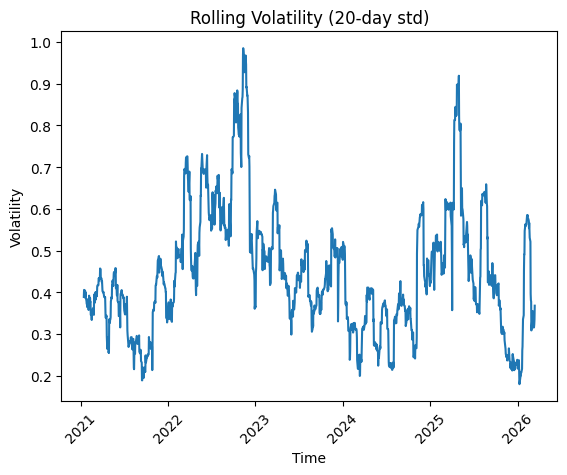

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(eurusd['timestamp'], eurusd['rolling_std'])
plt.title('Rolling Volatility (20-day std)')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.show()